# Common

### Import


In [1]:
import ee
import geemap
import sys
sys.path.append('../.')
from src.preprocessing_heatMap_helper import *

%load_ext autoreload
%autoreload 2

Failed to read module file 'C:\Users\Surface\anaconda3\Lib\functools.py' for module 'functools': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\nairobi_env\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\nairobi_env\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Surface\anaconda3\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen im

### Initialize the Google Earth Engine API

In [ ]:
ee.Authenticate(auth_mode='localhost')
ee.Initialize(project= 'ee-nairobi-heatmap')

# Part 1 - Nairobi Heatmap 
This first part of the notebook focus on getting a heatmap of Nairobi. 

### Nairobi boundary
This boudary have been [downloaded](https://data.humdata.org/dataset/cod-ab-ken). The one from the FAO is a bit shifted (NE). But in fact the one from the humdata website is also shifted (NNW).

In [ ]:
# this administrative boundary where added by hand into the assets of my GEE project, it also leads to a shift
nairobi_boundary = ee.FeatureCollection("projects/ee-nairobi-heatmap/assets/ken_admin2") \
                    .filter(ee.Filter.eq('adm1_name', 'Nairobi'))

# Here is my original cloud code but it leads to a shift in the boundaries
# nairobi_boundary = ee.FeatureCollection("FAO/GAUL/2015/level2") \
#                     .filter(ee.Filter.eq('ADM2_NAME', 'Nairobi'))

### Map visualisation

Processing LST for 2020...
Generating URL ...
Please wait ...
Data downloaded to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\notebooks\results\lst_geotiffs\LST_2020.tif
Saved: results\lst_geotiffs\LST_2020.tif
Processing LST for 2022...
Generating URL ...
Please wait ...
Data downloaded to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\notebooks\results\lst_geotiffs\LST_2022.tif
Saved: results\lst_geotiffs\LST_2022.tif
Processing LST for 2024...
Generating URL ...
Please wait ...
Data downloaded to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\notebooks\results\lst_geotiffs\LST_2024.tif
Saved: results\lst_geotiffs\LST_2024.tif


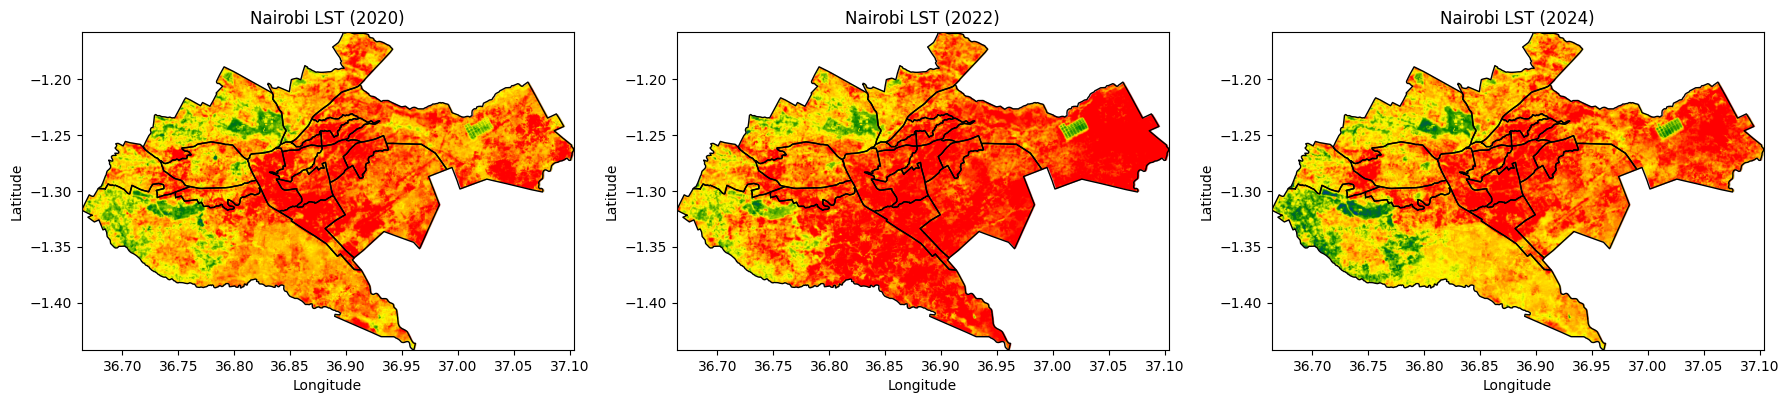

In [19]:
# To plot the Land Surface Temperature and Also download the GeoTIFF maps to 
# show them in the website
fig = heatmap_overyears_of(nairobi_boundary, [2020, 2022, 2024])

### Web export

In [2]:
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from src.export_web_maps import export_raster_for_web

lst_cmap = LinearSegmentedColormap.from_list("lst", ['blue', 'green', 'yellow', 'orange', 'red'])

with rasterio.open("results/lst_geotiffs/LST_2020.tif") as src:
    lst_array = src.read(1)
    lst_grid = {'bounds': src.bounds, 'crs': src.crs}

export_raster_for_web(lst_array, lst_grid, "lst_2020", 
                        cmap=lst_cmap, vmin=20, vmax=40)

with rasterio.open("results/lst_geotiffs/LST_2022.tif") as src:
    lst_array = src.read(1)
    lst_grid = {'bounds': src.bounds, 'crs': src.crs}

export_raster_for_web(lst_array, lst_grid, "lst_2022", 
                        cmap=lst_cmap, vmin=20, vmax=40)

with rasterio.open("results/lst_geotiffs/LST_2024.tif") as src:
    lst_array = src.read(1)
    lst_grid = {'bounds': src.bounds, 'crs': src.crs}

export_raster_for_web(lst_array, lst_grid, "lst_2024", 
                        cmap=lst_cmap, vmin=20, vmax=40)


Exported 'lst_2020' to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\results\web
Exported 'lst_2022' to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\results\web
Exported 'lst_2024' to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\results\web


### Personal Conclusion
Overall the map seems pretty correct and accurate.

__Problems:__
- holes inside the map which may lead to futur problematic behavior $\rarr$ __solve__ using interpollation (the data was actually missing inside the band I was looking to)
- boudary a shifted to the north of approximatly 300 meters $\rarr$ problematic when layered over a classic map but not wrong  $\rarr$ __solve__ by removing the overlay of my map above the google earth one. 

# Part 2 - Identifying Formal/Informal settlements



In [ ]:
from Nairobi_Heat_Vulnerability_Assessment.src.preprocessing_heatMap_helper import mask_s2_clouds, classify_settlements

### Sentinel-2 
Load Sentinel-2 Data (Higher 10m resolution for better detail)

In [ ]:
s2_median = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
    .filterBounds(nairobi_boundary) \
    .filterDate('2024-01-01', '2024-12-31') \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
    .map(mask_s2_clouds) \
    .median()


### Classify the settlements

In [ ]:
settlement_map = classify_settlements(s2_median).clip(nairobi_boundary)

### Visualize 

In [ ]:
settlement_vis = {'min': 0, 'max': 1, 'palette': ['#a1d99b', '#e31a1c']}
Map = visualize_data(settlement_map, nairobi_boundary   \
    ,'Nairobi: Formal (Green) vs Informal (Red)'    \
        , vis_params=settlement_vis \
        , zoom=12, opacity=0.9)
Map

### Personal Conclusion
When searching for a map representing informal settlements we find this, we can see that our map over detect (Improving idea: finetune parameters of the filtering function and use the temperature as an indicator).

<img src="..\data\images\informal_settlements.png" width="100%">